## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/house_prices_practice.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [2]:
# Display basic information about the dataset
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [3]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


In [4]:
# Check for missing values
print("\nMissing values count per column:")
display(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))


Missing values count per column:


,0


## 2. Feature Engineering and Correlation Analysis


Correlations with SalePrice:
SalePrice        1.000000
SalePrice_log    0.982807
GrLivArea        0.745095
OverallQual      0.352899
GarageCars       0.351321
FullBath         0.273731
TotalBsmtSF      0.250178
YearBuilt        0.222142
BedroomAbvGr     0.014113
Id              -0.025416
LotArea         -0.038982
Name: SalePrice, dtype: float64


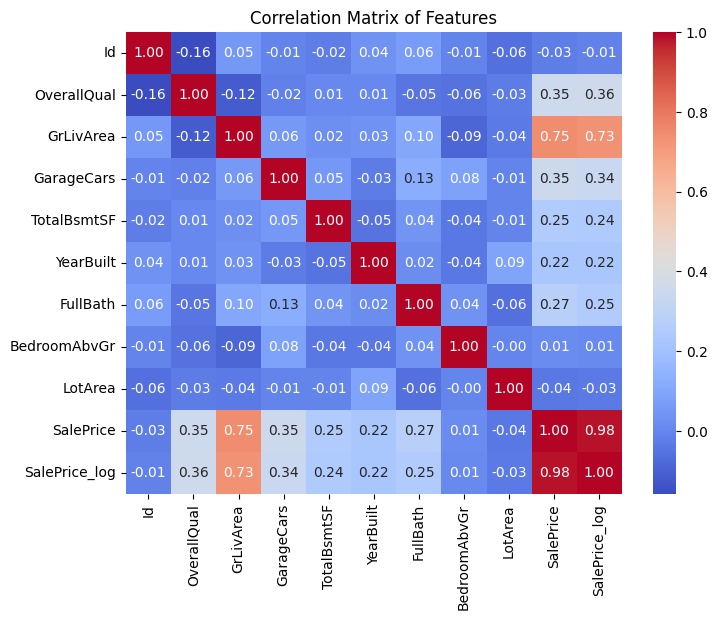

In [15]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display correlations with SalePrice
print("\nCorrelations with SalePrice:")
print(correlation_matrix['SalePrice'].sort_values(ascending=False))

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## 3. Handling Skewed Distributions and Feature Transformation

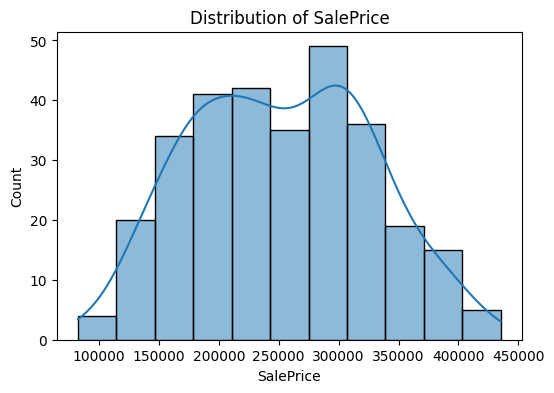

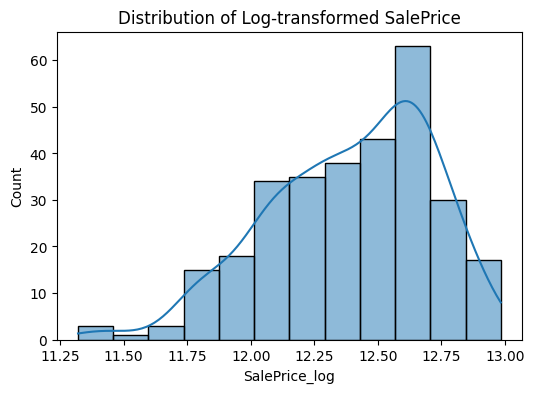


Skewness of numerical features:
 GarageCars       0.205801
BedroomAbvGr     0.056307
YearBuilt        0.013448
OverallQual      0.012340
GrLivArea       -0.008859
FullBath        -0.044276
TotalBsmtSF     -0.134456
LotArea         -0.183169
SalePrice_log   -0.572648
dtype: float64

DataFrame after transformations:


,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice,SalePrice_log
0,1,7,1560,0,1658,1969,2,1,8059,177106,12.084509
1,2,4,2827,2,1319,2012,3,4,13530,301044,12.615015
2,3,8,3920,0,841,2010,1,4,9010,360609,12.795552
3,4,5,3044,0,1058,1998,0,4,13207,240556,12.390712
4,5,7,801,1,2428,2020,0,1,9117,193656,12.173844


In [18]:
# Visualize the distribution of SalePrice
plt.figure(figsize=(6,4))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.show()

# Apply log transformation to SalePrice if skewed
df['SalePrice_log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(6,4))
sns.histplot(df['SalePrice_log'], kde=True)
plt.title('Distribution of Log-transformed SalePrice')
plt.show()

# Identify skewed numerical features (excluding 'Id' and the target variable)
numeric_feats = df.select_dtypes(include=np.number).columns.tolist()
numeric_feats.remove('Id')
numeric_feats.remove('SalePrice')

# Calculate skewness for numerical features
skewed_feats = df[numeric_feats].skew().sort_values(ascending=False)
print("\nSkewness of numerical features:\n", skewed_feats)

# Apply log transformation to highly skewed features
# A common threshold for high skewness is a value greater than 0.75 or 1
skewness_threshold = 0.75
high_skew_features = skewed_feats[skewed_feats > skewness_threshold].index

for feat in high_skew_features:
    df[feat] = np.log1p(df[feat])
    print(f"Log-transformed feature: {feat}")

# Display the first few rows of the DataFrame with transformed features
print("\nDataFrame after transformations:")
display(df.head())

## 4. Data Splitting and Model Building

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define features (X) and target (y)
# We use the log-transformed SalePrice as the target
X = df.drop(['Id', 'SalePrice', 'SalePrice_log'], axis=1)
y = df['SalePrice_log']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# --- Random Forest Regressor ---
print("\n--- Training Random Forest Regressor ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest MAE: {rf_mae:.4f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

# --- XGBoost Regressor ---
print("\n--- Training XGBoost Regressor ---")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test)

# Evaluate the XGBoost model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")
print(f"XGBoost R2 Score: {xgb_r2:.4f}")

Training set shape: (240, 8)
Testing set shape: (60, 8)

--- Training Random Forest Regressor ---
Random Forest RMSE: 0.1236
Random Forest MAE: 0.0991
Random Forest R2 Score: 0.8503

--- Training XGBoost Regressor ---
XGBoost RMSE: 0.1202
XGBoost MAE: 0.0922
XGBoost R2 Score: 0.8585


## 5. Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

# --- Hyperparameter Tuning for Random Forest Regressor ---
print("\n--- Hyperparameter Tuning for Random Forest Regressor ---")

# Define the parameter grid to search
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [0.6, 0.8, 1.0],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {rf_grid_search.best_params_}")
print(f"Best RMSE for Random Forest (on CV sets): {np.sqrt(-rf_grid_search.best_score_):.4f}")

best_rf_model = rf_grid_search.best_estimator_
rf_tuned_predictions = best_rf_model.predict(X_test)

rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_predictions))
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_predictions)
rf_tuned_r2 = r2_score(y_test, rf_tuned_predictions)

print(f"Tuned Random Forest RMSE on Test Set: {rf_tuned_rmse:.4f}")
print(f"Tuned Random Forest MAE on Test Set: {rf_tuned_mae:.4f}")
print(f"Tuned Random Forest R2 Score on Test Set: {rf_tuned_r2:.4f}")


--- Hyperparameter Tuning for Random Forest Regressor ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Random Forest: {'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 300}
Best RMSE for Random Forest (on CV sets): 0.1385
Tuned Random Forest RMSE on Test Set: 0.1171
Tuned Random Forest MAE on Test Set: 0.0916
Tuned Random Forest R2 Score on Test Set: 0.8656


In [12]:
# --- Hyperparameter Tuning for XGBoost Regressor ---
print("\n--- Hyperparameter Tuning for XGBoost Regressor ---")

# Define the parameter grid to search
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9]
}

xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print(f"Best parameters for XGBoost: {xgb_grid_search.best_params_}")
print(f"Best RMSE for XGBoost (on CV sets): {np.sqrt(-xgb_grid_search.best_score_):.4f}")

best_xgb_model = xgb_grid_search.best_estimator_
xgb_tuned_predictions = best_xgb_model.predict(X_test)

xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, xgb_tuned_predictions))
xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_predictions)
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_predictions)

print(f"Tuned XGBoost RMSE on Test Set: {xgb_tuned_rmse:.4f}")
print(f"Tuned XGBoost MAE on Test Set: {xgb_tuned_mae:.4f}")
print(f"Tuned XGBoost R2 Score on Test Set: {xgb_tuned_r2:.4f}")


--- Hyperparameter Tuning for XGBoost Regressor ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best RMSE for XGBoost (on CV sets): 0.0915
Tuned XGBoost RMSE on Test Set: 0.0775
Tuned XGBoost MAE on Test Set: 0.0585
Tuned XGBoost R2 Score on Test Set: 0.9412


## 6. Error Analysis and Visualization


--- Error Analysis and Visualization ---

Comparison of Tuned Models:
Random Forest (Tuned) - RMSE: 0.1171, MAE: 0.0916, R2: 0.8656
XGBoost (Tuned) - RMSE: 0.0775, MAE: 0.0585, R2: 0.9412

The best performing model is: XGBoost
Best Model (Tuned) - RMSE: 0.0775, MAE: 0.0585, R2: 0.9412


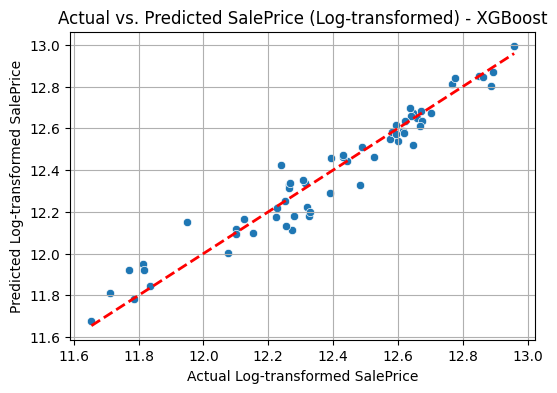

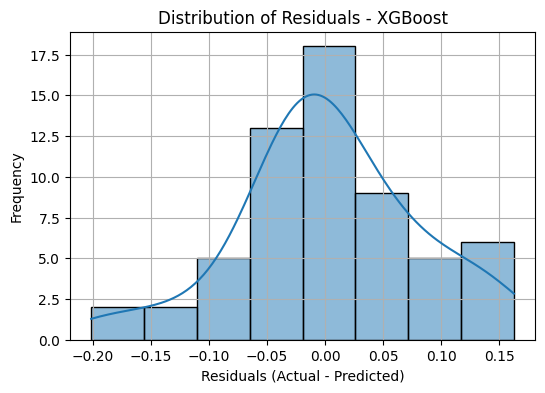

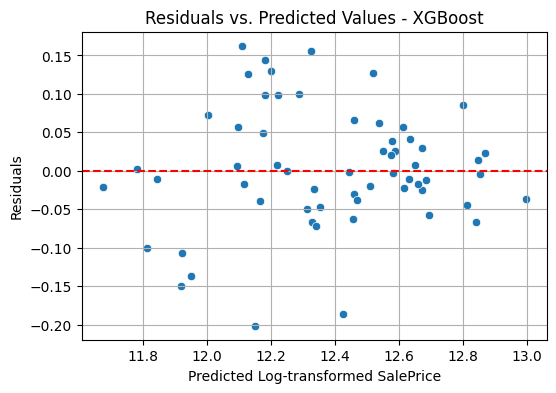

In [16]:
print("\n--- Error Analysis and Visualization ---")

# Compare best models (Random Forest vs XGBoost)
print("\nComparison of Tuned Models:")
print(f"Random Forest (Tuned) - RMSE: {rf_tuned_rmse:.4f}, MAE: {rf_tuned_mae:.4f}, R2: {rf_tuned_r2:.4f}")
print(f"XGBoost (Tuned) - RMSE: {xgb_tuned_rmse:.4f}, MAE: {xgb_tuned_mae:.4f}, R2: {xgb_tuned_r2:.4f}")

# Determine the best model based on RMSE
if rf_tuned_rmse < xgb_tuned_rmse:
    best_model_name = "Random Forest"
    best_predictions = rf_tuned_predictions
    best_rmse = rf_tuned_rmse
    best_mae = rf_tuned_mae
    best_r2 = rf_tuned_r2
else:
    best_model_name = "XGBoost"
    best_predictions = xgb_tuned_predictions
    best_rmse = xgb_tuned_rmse
    best_mae = xgb_tuned_mae
    best_r2 = xgb_tuned_r2

print(f"\nThe best performing model is: {best_model_name}")
print(f"Best Model (Tuned) - RMSE: {best_rmse:.4f}, MAE: {best_mae:.4f}, R2: {best_r2:.4f}")

# Create a DataFrame for actual vs. predicted values for the best model
results_df = pd.DataFrame({'Actual SalePrice_log': y_test, 'Predicted SalePrice_log': best_predictions})
results_df['Residuals'] = results_df['Actual SalePrice_log'] - results_df['Predicted SalePrice_log']

# Visualize actual vs. predicted values
plt.figure(figsize=(6,4))
sns.scatterplot(x='Actual SalePrice_log', y='Predicted SalePrice_log', data=results_df)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs. Predicted SalePrice (Log-transformed) - {best_model_name}')
plt.xlabel('Actual Log-transformed SalePrice')
plt.ylabel('Predicted Log-transformed SalePrice')
plt.grid(True)
plt.show()

# Visualize residuals
plt.figure(figsize=(6,4))
sns.histplot(results_df['Residuals'], kde=True)
plt.title(f'Distribution of Residuals - {best_model_name}')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='Predicted SalePrice_log', y='Residuals', data=results_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title(f'Residuals vs. Predicted Values - {best_model_name}')
plt.xlabel('Predicted Log-transformed SalePrice')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

In [19]:
import joblib

# Save the best Random Forest model
joblib.dump(best_rf_model, 'best_random_forest_model.pkl')
print("Best Random Forest model saved as 'best_random_forest_model.pkl'")

# Save the best XGBoost model
joblib.dump(best_xgb_model, 'best_xgboost_model.pkl')
print("Best XGBoost model saved as 'best_xgboost_model.pkl'")

Best Random Forest model saved as 'best_random_forest_model.pkl'
Best XGBoost model saved as 'best_xgboost_model.pkl'
